In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the original Heart Failure dataset
df = pd.read_csv(
    "../heart_failure_clinical_records_dataset-selected-columns.csv"
)

# Display first 5 rows
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
0,75.0,0,582,0,20,1,265000.00,1.9,130,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0


In [3]:
# Check missing values in the original dataset
original_missing_values = df.isnull().sum()

print("Missing Values in Original Dataset:")
print(original_missing_values)

print(
    "\nTotal Missing Values:",
    original_missing_values.sum()
)

Missing Values in Original Dataset:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
dtype: int64

Total Missing Values: 0


In [4]:
# Create a copy to protect the original dataset
df_missing = df.copy()

print("Original Dataset Shape:", df.shape)
print("Copied Dataset Shape:", df_missing.shape)

Original Dataset Shape: (299, 10)
Copied Dataset Shape: (299, 10)


In [5]:
# Introduce missing values for learning purposes

df_missing.loc[5:14, "age"] = np.nan

df_missing.loc[
    [20, 25, 30, 35, 40],
    "serum_creatinine"
] = np.nan

df_missing.loc[
    [50, 55, 60, 65],
    "platelets"
] = np.nan

df_missing.loc[
    [70, 75, 80],
    "diabetes"
] = np.nan

# Display selected rows containing introduced missing values
df_missing.loc[
    [5, 10, 20, 30, 50, 60, 70, 80]
]

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
5,NaN,1,47,0.0,40,1,204000.00,2.1,132,1
10,NaN,1,81,0.0,38,1,368000.00,4.0,131,1
20,65.0,1,52,0.0,25,1,276000.00,NaN,137,0
30,94.0,0,582,1.0,38,1,263358.03,NaN,134,1
50,68.0,1,577,0.0,25,1,NaN,1.0,138,1
60,45.0,0,7702,1.0,25,1,NaN,1.0,139,1
70,41.0,0,148,NaN,40,0,374000.00,0.8,140,1
80,70.0,0,69,NaN,40,0,293000.00,1.7,136,0


In [7]:
# Count missing values in each column
missing_count = df_missing.isnull().sum()

missing_count

age                         10
anaemia                      0
creatinine_phosphokinase     0
diabetes                     3
ejection_fraction            0
high_blood_pressure          0
platelets                    4
serum_creatinine             5
serum_sodium                 0
sex                          0
dtype: int64

In [8]:
# Calculate total missing values in the complete DataFrame
total_missing_values = df_missing.isnull().sum().sum()

print("Total Missing Values:", total_missing_values)

Total Missing Values: 22


In [10]:
# Calculate missing-value percentage for each column
missing_percentage = (
    df_missing.isnull().sum()
    / len(df_missing)
) * 100

missing_percentage

age                         3.344482
anaemia                     0.000000
creatinine_phosphokinase    0.000000
diabetes                    1.003344
ejection_fraction           0.000000
high_blood_pressure         0.000000
platelets                   1.337793
serum_creatinine            1.672241
serum_sodium                0.000000
sex                         0.000000
dtype: float64

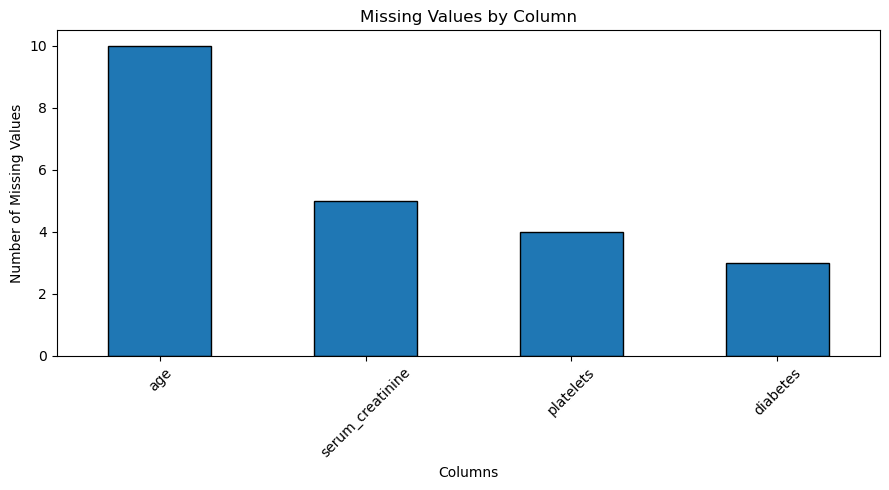

In [12]:
# Select only columns containing missing values
missing_count_for_plot = missing_count[
    missing_count > 0
].sort_values(ascending=False)

# Create bar plot
plt.figure(figsize=(9, 5))

missing_count_for_plot.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()